# Preparation

## Import and config

In [38]:
# Make the `utils` helper package importable regardless of CWD.
# Layout: bakeoff/scripts/analysis/utils/{parser,util}.py
import sys
from pathlib import Path as _PathBootstrap
_HERE = _PathBootstrap.cwd()
for _cand in [_HERE / 'scripts' / 'analysis',  # CWD = bakeoff/
              _HERE,                            # CWD = bakeoff/scripts/analysis/
              _HERE / 'bakeoff' / 'scripts' / 'analysis']:
    if (_cand / 'utils' / '__init__.py').exists() and str(_cand) not in sys.path:
        sys.path.insert(0, str(_cand))
        break

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu

In [39]:
import matplotlib.patches as _mpatches

_TAB10 = plt.get_cmap("tab10")
TOOL_COLORS = {
    "Centrifuge":  _TAB10(0),
    "Centrifuger": _TAB10(1),
    "Kraken2":     _TAB10(2),
    "Ganon2":      _TAB10(3),
    "ganon2":      _TAB10(3),
    "Sourmash":    _TAB10(4),
    "sourmash":    _TAB10(4),
    "Sylph":       _TAB10(5),
    "sylph":       _TAB10(5),
}

VARIANT_ORDER = ["default", "illumina", "unified"]
VARIANT_SHORT = {"default": "def", "illumina": "ill", "unified": "uni"}
_VARIANT_ALPHA = {"default": 0.35, "unified": 0.95}  # matches detection / abundance figures
_ILLUMINA_FACE = "lightgray"
_ILLUMINA_ALPHA = 0.40

def _tool_color(tool):
    return TOOL_COLORS.get(str(tool), (0.5, 0.5, 0.5, 1.0))

def _style_box(patch, tool_color, variant):
    if variant == "illumina":
        patch.set_facecolor(_ILLUMINA_FACE)
        patch.set_alpha(_ILLUMINA_ALPHA)
        patch.set_edgecolor("black")
        patch.set_linewidth(1.0)
    else:
        patch.set_facecolor(tool_color)
        patch.set_alpha(_VARIANT_ALPHA[variant])
        patch.set_edgecolor("black")
        patch.set_linewidth(0.9)

def _style_boxes_by_tool(ax, tool_order, *, variant_order=VARIANT_ORDER,
                         dodge_offset=0.17):
    """Post-process a seaborn boxplot: each box's (tool, variant) is
    inferred from its x-centroid, then the box is repainted with the
    tool's color and the variant's fill style.

    Robust against seaborn's hue-major emission order in ax.patches
    and against missing (tool, variant) combinations."""
    x_off = {"default": -dodge_offset, "illumina": 0.0, "unified": dodge_offset}
    variants_sorted = list(variant_order)
    boxes = [p for p in ax.patches if isinstance(p, _mpatches.PathPatch)]
    for patch in boxes:
        verts = patch.get_path().vertices
        if verts.size == 0:
            continue
        x_center = float(np.mean(verts[:, 0]))
        # nearest tool index (x is integer-spaced at 0, 1, 2, ...)
        ti = int(round(x_center))
        if not (0 <= ti < len(tool_order)):
            continue
        residual = x_center - ti
        # snap to nearest variant offset
        variant = min(variants_sorted, key=lambda v: abs(x_off[v] - residual))
        _style_box(patch, _tool_color(tool_order[ti]), variant)

def _draw_variant_legend(ax, *, loc="upper right", fontsize=8, title_fontsize=10):
    handles = [
        _mpatches.Patch(facecolor="gray", alpha=_VARIANT_ALPHA["default"],
                        edgecolor="black", linewidth=0.9, label="default DB"),
        _mpatches.Patch(facecolor=_ILLUMINA_FACE, alpha=_ILLUMINA_ALPHA,
                        edgecolor="black", linewidth=1.0, label="illumina"),
        _mpatches.Patch(facecolor="gray", alpha=_VARIANT_ALPHA["unified"],
                        edgecolor="black", linewidth=0.9, label="unified DB"),
    ]
    leg = ax.legend(handles=handles, title="variant", frameon=True,
                    edgecolor="black", facecolor="white",
                    fontsize=fontsize, title_fontsize=title_fontsize, loc=loc)
    leg.get_frame().set_linewidth(0.8)
    return leg

def _draw_brackets(ax, tool, drawn, x_center_map, x_offsets,
                   y0, y_step, bar_h, text_dy, *, label_fontsize=9):
    """Render the stack of significance brackets above one tool column.
    `drawn` is a list of (a_var, b_var, label).  Each bracket spans
    from the box center of a_var to the box center of b_var, with a
    foot swatch at each end whose style matches the connected box."""
    if not drawn:
        return
    xC = x_center_map[tool]
    color = _tool_color(tool)
    for k, (a_var, b_var, label) in enumerate(drawn):
        y = y0 + k * y_step
        x1 = xC + x_offsets[a_var]
        x2 = xC + x_offsets[b_var]
        ax.plot([x1, x1, x2, x2], [y, y + bar_h, y + bar_h, y],
                color="black", lw=1.1, clip_on=False)
        ax.text((x1 + x2) / 2.0, y + bar_h + text_dy,
                label, ha="center", va="bottom",
                fontsize=label_fontsize)

def _set_mixed_title(ax, main, small, *, main_fontsize=18, small_fontsize=12, pad=0):
    """Set a one-line axis title with two font sizes: a large `main`
    portion followed by a smaller `small` portion (e.g. a threshold
    annotation).  Uses an HPacker so both share a baseline and the
    combined block stays centered above the axes."""
    from matplotlib.offsetbox import HPacker, TextArea, AnchoredOffsetbox
    main_box  = TextArea(main,  textprops=dict(fontsize=main_fontsize))
    small_box = TextArea(small, textprops=dict(fontsize=small_fontsize))
    packer = HPacker(children=[main_box, small_box],
                     align="baseline", pad=0, sep=8)
    title_box = AnchoredOffsetbox(
        loc="lower center", child=packer,
        bbox_to_anchor=(0.5, 1.0), bbox_transform=ax.transAxes,
        pad=0, frameon=False, borderpad=pad,
    )
    ax.add_artist(title_box)


In [40]:
from pathlib import Path

from utils.alpha_div import find_latest_cohort_cache
from utils.results   import find_latest_dyn_prep_ts, save_csv, save_fig

SAVE = True

# Cohorts to plot
PLOT_SINGLE_COHORT = "ont_qiagen"   # one-cohort plot
PLOT_TWO_COHORTS = ("pacbio", "ont_zymo")  # two-cohort plot

# Threshold (purely a notebook knob — sweep freely; only cells below the
# loader need to re-run, the cohort cache stays in memory).
MIN_ABUNDANCE = 0.1  # percent units; 0.1 means 0.1%

# Validators (used by the loader cell below)
VALID_COHORTS = {"pacbio", "ont_qiagen", "ont_zymo"}

def _normalize_single_cohort(value, label: str) -> str:
    if isinstance(value, (list, tuple)):
        if len(value) != 1:
            raise ValueError(f"{label} must be a single cohort, got: {value}")
        value = value[0]
    value = str(value)
    if value not in VALID_COHORTS:
        raise ValueError(f"{label} must be one of {sorted(VALID_COHORTS)}, got: {value}")
    return value

def _normalize_two_cohorts(values, label: str) -> tuple[str, str]:
    if isinstance(values, str):
        raise ValueError(f"{label} must contain two cohorts, got a single string: {values}")
    values = tuple(str(v) for v in values)
    if len(values) != 2:
        raise ValueError(f"{label} must contain exactly two cohorts, got: {values}")
    bad = [v for v in values if v not in VALID_COHORTS]
    if bad:
        raise ValueError(f"{label} contains invalid cohorts {bad}; choose from {sorted(VALID_COHORTS)}")
    return values

PLOT_SINGLE_COHORT = _normalize_single_cohort(PLOT_SINGLE_COHORT, "PLOT_SINGLE_COHORT")
PLOT_TWO_COHORTS   = _normalize_two_cohorts(PLOT_TWO_COHORTS, "PLOT_TWO_COHORTS")

# Paths
#   RESULTS_ROOT : bakeoff results tree (cohort cache lives under
#                  RESULTS_ROOT/metadata/<ts>/dyn-prep/tables/cohorts/)
#   CACHE_DIR    : auto-resolved to the most recent timestamped cache
#                  written by dyn_prep.py; override below to pin a run.
#   OUTPUT_BASE  : where this notebook writes figures + per-sample TSVs
RESULTS_ROOT = Path("/home/Users/pacbio_bakeoff/bakeoff/results")
TS           = find_latest_dyn_prep_ts(RESULTS_ROOT)  # or pin: TS = "YYYYMMDD_HHMMSS"
CACHE_DIR    = find_latest_cohort_cache(RESULTS_ROOT)
OUTPUT_BASE  = RESULTS_ROOT / TS / "dyn-alpha-div"

print("PLOT_SINGLE_COHORT :", PLOT_SINGLE_COHORT)
print("PLOT_TWO_COHORTS   :", PLOT_TWO_COHORTS)
print("MIN_ABUNDANCE      :", MIN_ABUNDANCE, "%")
print("ts                 :", TS)
print("CACHE_DIR          :", CACHE_DIR)
print(f"OUTPUT_BASE        : {OUTPUT_BASE}  (SAVE={SAVE})")


PLOT_SINGLE_COHORT : ont_qiagen
PLOT_TWO_COHORTS   : ('pacbio', 'ont_zymo')
MIN_ABUNDANCE      : 0.1 %
ts                 : 20260713_015342_dyn
CACHE_DIR          : /home/Users/pacbio_bakeoff/bakeoff/results/prepared/20260713_015342_dyn/dyn-prep/tables/cohorts
OUTPUT_BASE        : /home/Users/pacbio_bakeoff/bakeoff/results/20260713_015342_dyn/dyn-alpha-div  (SAVE=True)


# Visualization

In [41]:
from pathlib import Path
import pandas as pd

from utils.alpha_div import load_cohort_plus_illumina

# Per-figure / per-table output dirs (threshold-tagged so sweeps don't
# overwrite). All downstream cells write under one of these two roots.
OUT_FIG = OUTPUT_BASE / "figures" / f"threshold_{MIN_ABUNDANCE}"
OUT_TAB = OUTPUT_BASE / "tables"  / f"threshold_{MIN_ABUNDANCE}"
OUT_FIG.mkdir(parents=True, exist_ok=True)
OUT_TAB.mkdir(parents=True, exist_ok=True)

COHORTS_TO_LOAD = list(dict.fromkeys([PLOT_SINGLE_COHORT, *PLOT_TWO_COHORTS]))

# Always read the cohort cache fresh from disk. Re-runs cost ~5–15 s and
# keep this notebook safe to re-execute after any cache rebuild (e.g.
# rerunning dyn_prep.py against updated reports) without a kernel restart.
long_dfs = {}
for cohort in COHORTS_TO_LOAD:
    long_dfs[cohort] = load_cohort_plus_illumina(CACHE_DIR, cohort)
    print(f"  [{cohort}] merged long DF: {long_dfs[cohort].shape}")
print(f"\nLoaded {len(long_dfs)} cohorts from {CACHE_DIR}")


  [ont_qiagen] merged long DF: (1119929, 38)
  [pacbio] merged long DF: (952706, 38)
  [ont_zymo] merged long DF: (1151328, 38)

Loaded 3 cohorts from /home/Users/pacbio_bakeoff/bakeoff/results/prepared/20260713_015342_dyn/dyn-prep/tables/cohorts


In [42]:
# Compute alpha-diversity for the current MIN_ABUNDANCE
# Re-run this cell after changing MIN_ABUNDANCE in the config cell.
# ~3s on a warm kernel; the loader above runs once per session.

from utils.alpha_div import compute_alpha_diversity

alpha_parts = []
for cohort, long_df in long_dfs.items():
    alpha = compute_alpha_diversity(long_df, min_abund_percent=MIN_ABUNDANCE)
    alpha["cohort"] = cohort
    # Prefix sample_id_core with cohort to avoid collisions across cohorts
    alpha["sample_id_core"] = cohort + "::" + alpha["sample_id_core"].astype(str)
    alpha_parts.append(alpha)

alpha_df = pd.concat(alpha_parts, ignore_index=True)

print(f"alpha_df shape : {alpha_df.shape}")
print(f"cohort counts  :\n{alpha_df['cohort'].value_counts(dropna=False).to_string()}")
print(f"assay counts   :\n{alpha_df['assay'].value_counts(dropna=False).to_string()}")


alpha_df shape : (1224, 12)
cohort counts  :
cohort
ont_zymo      432
ont_qiagen    408
pacbio        384
assay counts   :
assay
illumina      648
ont_zymo      216
ont_qiagen    192
pacbio        168


In [43]:
# Restrict illumina rows to per-cohort intersection
# Each cohort's TSV bundles the full illumina baseline. For the MWU
# comparisons (raw and FDR-corrected) we want a sample-matched baseline,
# so drop illumina rows whose sample_id_core is absent from this cohort.
# Example: pacbio has 7 samples → keep only those 7 illumina rows, not
# all 9. Applies to BOTH the existing Figure 10 and the new BH-FDR section.

assert "sample_id_core" in alpha_df.columns, \
    "alpha_df needs 'sample_id_core' column for the intersection filter"

alpha_df_unfiltered = alpha_df.copy()  # kept for reference / debugging

_keep_parts = []
for _cohort in alpha_df["cohort"].astype(str).unique():
    _cdf = alpha_df[alpha_df["cohort"].astype(str) == _cohort]
    _non_ilu = _cdf[_cdf["assay"].astype(str).str.lower() != "illumina"]
    _ilu     = _cdf[_cdf["assay"].astype(str).str.lower() == "illumina"]
    _cohort_cores = set(_non_ilu["sample_id_core"].astype(str).unique())
    _ilu_kept = _ilu[_ilu["sample_id_core"].astype(str).isin(_cohort_cores)]
    _keep_parts.append(pd.concat([_non_ilu, _ilu_kept], ignore_index=True))

alpha_df = pd.concat(_keep_parts, ignore_index=True)
del _keep_parts

print("=== Per-cohort sample counts after intersection filter ===")
for _c in sorted(alpha_df["cohort"].astype(str).unique()):
    _sub = alpha_df[alpha_df["cohort"].astype(str) == _c]
    _n_cohort = _sub[_sub["assay"].astype(str).str.lower() != "illumina"]["sample_id_core"].astype(str).nunique()
    _n_match  = _sub[_sub["assay"].astype(str).str.lower() == "illumina"]["sample_id_core"].astype(str).nunique()
    _n_dropped = alpha_df_unfiltered[
        (alpha_df_unfiltered["cohort"].astype(str) == _c)
        & (alpha_df_unfiltered["assay"].astype(str).str.lower() == "illumina")
    ]["sample_id_core"].astype(str).nunique() - _n_match
    print(f"  {_c:12s}  cohort_n={_n_cohort:>2}  illumina_matched={_n_match:>2}  illumina_dropped={_n_dropped:>2}")


=== Per-cohort sample counts after intersection filter ===
  ont_qiagen    cohort_n= 8  illumina_matched= 8  illumina_dropped= 1
  ont_zymo      cohort_n= 9  illumina_matched= 9  illumina_dropped= 0
  pacbio        cohort_n= 7  illumina_matched= 7  illumina_dropped= 2


In [44]:
# Persist per-sample alpha-div table to disk for reviewer auditability.
# Same threshold subdir as the figures and MWU stats; one row per
# (cohort, assay, sample_id_core, tool_db, rank) carrying Shannon,
# Simpson, richness, classified_fraction, and kept_fraction.
_alpha_path = OUT_TAB / "alpha_div_per_sample.tsv"
save_csv(alpha_df, _alpha_path, SAVE, sep="\t", index=False)
print(f"[saved] {_alpha_path}  ({len(alpha_df)} rows)")


[saved] /home/Users/pacbio_bakeoff/bakeoff/results/20260713_015342_dyn/dyn-alpha-div/tables/threshold_0.1/alpha_div_per_sample.tsv  (1152 rows)


In [45]:
def get_significance_label(p):
    """Convert p-value to 'n.s.', '*', '**', '***'."""
    if p <= 0.001:
        return "***"
    elif p <= 0.01:
        return "**"
    elif p <= 0.05:
        return "*"
    else:
        return "n.s."

def _mw_label(a, b):
    """Return (p, sig, p_text)."""
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]
    if a.size == 0 or b.size == 0:
        return np.nan, "n.a.", "n.a."

    p = mannwhitneyu(a, b, alternative="two-sided").pvalue
    sig = get_significance_label(p)
    p_text = f"p={p:.1e}"
    return p, sig, p_text


[saved] /home/Users/pacbio_bakeoff/bakeoff/results/20260713_015342_dyn/dyn-alpha-div/figures/threshold_0.1/ont_qiagen_alpha_div_rawp.png


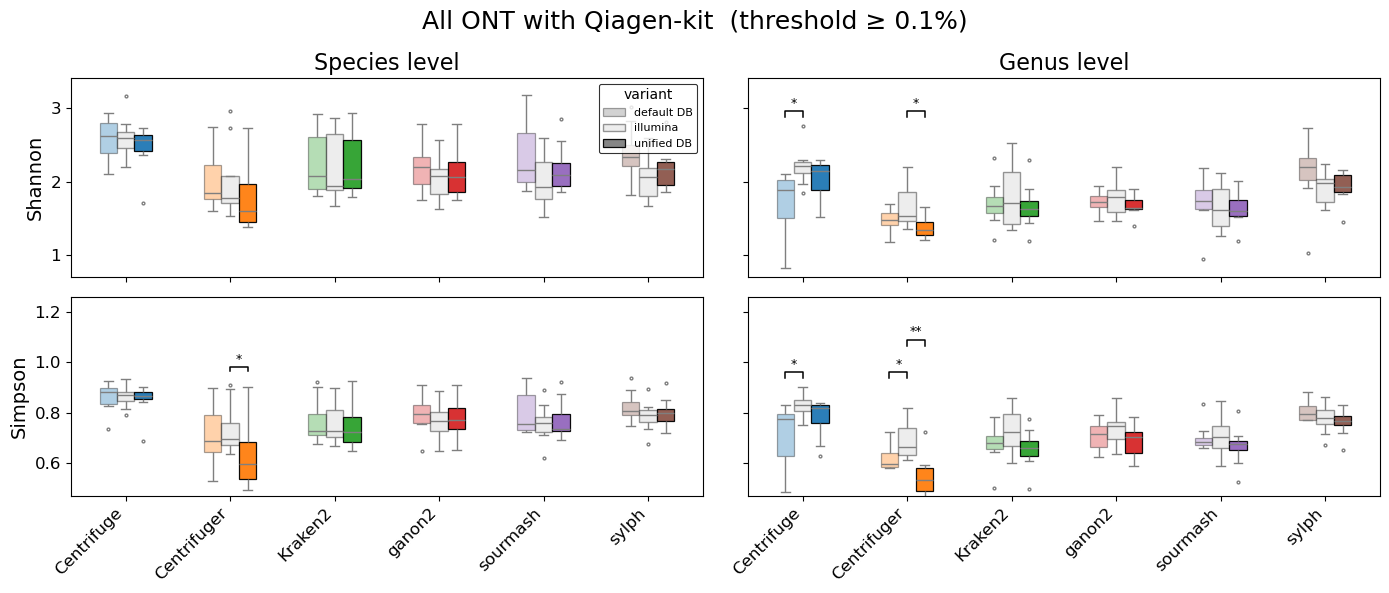

In [46]:
def plot_alpha_db_with_illumina_panel(
    alpha_df: pd.DataFrame,
    *,
    cohort=None,
    metrics=("shannon", "simpson"),
    ranks=("species", "genus"),
    illumina_pick_rule=None,
    tool_order=None,
    figsize=(14, 6),
    box_width=0.50,
    dodge_offset=0.17,
    headroom_frac=0.22,
    show_only_significant=True,
    alpha_sig=0.05,
    sig_lookup=None,
    y0_frac=0.06,
    y_step_frac=0.22,
    bar_h_frac=0.04,
    text_dy_frac=0.010,
    filename=None,
):
    """
    2x2 panel: rows = metrics, cols = ranks.
    Variants left -> right: default, illumina, unified.
    Boxes are colored by tool (TOOL_COLORS); variant is encoded by
    fill style (default = faint fill, illumina = hollow, unified = solid).
    MWU comparisons per tool: default vs illumina, default vs unified,
    illumina vs unified.
    """
    df = alpha_df.copy()

    if "assay" not in df.columns:
        raise ValueError("alpha_df must contain column 'assay' (e.g. 'illumina' vs cohort).")
    if "cohort" not in df.columns:
        if cohort is None:
            raise ValueError("Pass cohort=... when alpha_df does not contain a 'cohort' column.")
        df["cohort"] = str(cohort)
    if cohort is None:
        non_illumina = df.loc[
            df["assay"].astype(str).str.lower().ne("illumina"),
            "cohort",
        ].astype(str).dropna().unique().tolist()
        if len(non_illumina) != 1:
            raise ValueError(f"alpha_df contains multiple cohorts {sorted(non_illumina)}; pass cohort='...'.")
        cohort = non_illumina[0]
    cohort = str(cohort)
    df = df[df["cohort"].astype(str) == cohort].copy()
    if df.empty:
        raise ValueError(f"No rows found for cohort={cohort!r}")

    if illumina_pick_rule is None:
        illumina_pick_rule = lambda tool: "unified"  # unified for every tool (Ganon2 unified rebuilt after a major bug fix)

    is_ilu = df["assay"].astype(str).str.lower().eq("illumina")
    df_ilu = df[is_ilu].copy()
    if not df_ilu.empty:
        df_ilu["ilu_keep_db"] = df_ilu["tool"].astype(str).map(illumina_pick_rule)
        df_ilu = df_ilu[df_ilu["db_mode"].astype(str) == df_ilu["ilu_keep_db"]].copy()
        df_ilu.drop(columns=["ilu_keep_db"], inplace=True, errors="ignore")
    df_cohort = df[~is_ilu].copy()
    df = pd.concat([df_cohort, df_ilu], ignore_index=True)

    df["variant"] = np.where(
        df["assay"].astype(str).str.lower().eq("illumina"),
        "illumina",
        df["db_mode"].astype(str),
    )
    df = df[df["variant"].isin(VARIANT_ORDER)].copy()

    df["tool"] = df["tool"].astype(str)
    if tool_order is None:
        tool_order = sorted(df["tool"].dropna().unique().tolist())

    variant_order = VARIANT_ORDER
    x_offsets = {"default": -dodge_offset, "illumina": 0.0, "unified": dodge_offset}
    # neutral palette: only used so seaborn renders boxes;
    # _style_boxes_by_tool then repaints them by tool.
    seed_palette = {v: "lightgray" for v in variant_order}

    fig, axes = plt.subplots(
        nrows=len(metrics), ncols=len(ranks),
        figsize=figsize, sharey="row", sharex=True,
    )
    if len(metrics) == 1 and len(ranks) == 1:
        axes = np.array([[axes]])
    elif len(metrics) == 1:
        axes = np.array([axes])
    elif len(ranks) == 1:
        axes = np.array([[a] for a in axes])

    if cohort == "pacbio":
        cohort_label = "All Pacbio"
    elif cohort == "ont_qiagen":
        cohort_label = "All ONT with Qiagen-kit"
    elif cohort == "ont_zymo":
        cohort_label = "All ONT with Zymo-kit"
    else:
        cohort_label = f"All {cohort}"
    fig.suptitle(f"{cohort_label}  (threshold ≥ {MIN_ABUNDANCE}%)", fontsize=18)

    for j, rk in enumerate(ranks):
        axes[0, j].set_title(f"{rk.capitalize()} level", fontsize=16)

    comparisons = [
        ("default", "illumina"),
        ("default", "unified"),
        ("illumina", "unified"),
    ]

    for i, metric in enumerate(metrics):
        for j, rk in enumerate(ranks):
            ax = axes[i, j]
            sub = df[df["rank"].astype(str) == rk].copy()
            sub = sub[sub[metric].notna()].copy()
            if sub.empty:
                ax.set_visible(False)
                continue

            sns.boxplot(
                data=sub, x="tool", y=metric, hue="variant",
                order=tool_order, hue_order=variant_order,
                palette=seed_palette, width=box_width,
                fliersize=2, linewidth=1, ax=ax,
            )
            _style_boxes_by_tool(ax, tool_order, variant_order=variant_order, dodge_offset=dodge_offset)

            if j == 0:
                ax.set_ylabel(metric.capitalize(), fontsize=14)
            else:
                ax.set_ylabel("")

            if i < len(metrics) - 1:
                ax.set_xlabel("")
                ax.tick_params(axis="x", labelbottom=False)
            else:
                ax.set_xlabel("")
                ax.tick_params(axis="x", labelrotation=45, labelsize=12, labelbottom=True)
                for t in ax.get_xticklabels():
                    t.set_ha("right")
            ax.tick_params(axis="y", labelsize=12)

            if i == 0 and j == 0:
                _draw_variant_legend(ax, loc="upper right", fontsize=8, title_fontsize=10)
            else:
                leg = ax.get_legend()
                if leg is not None:
                    leg.remove()

            data_max = sub[metric].max()
            data_min = sub[metric].min()
            if not np.isfinite(data_max):
                continue
            yr = max(float(data_max - data_min), 1e-6)
            bar_h   = bar_h_frac   * yr
            text_dy = text_dy_frac * yr
            y0      = float(data_max + y0_frac * yr)
            y_step  = y_step_frac  * yr
            x_center_map = {tool: idx for idx, tool in enumerate(tool_order)}

            per_tool_draw = {}
            max_drawn = 0
            for tool in tool_order:
                df_tool = sub[sub["tool"] == tool]
                drawn = []
                if df_tool.empty:
                    per_tool_draw[tool] = drawn
                    continue
                for (a_var, b_var) in comparisons:
                    vals_a = df_tool[df_tool["variant"] == a_var][metric].values
                    vals_b = df_tool[df_tool["variant"] == b_var][metric].values
                    if sig_lookup is not None:
                        _key = (str(cohort), str(rk), str(metric), str(tool), f"{a_var} vs {b_var}")
                        _q = sig_lookup.get(_key, np.nan)
                        if not np.isfinite(_q):
                            continue
                        p, sig, p_text = float(_q), get_significance_label(float(_q)), f"q={float(_q):.1e}"
                    else:
                        p, sig, p_text = _mw_label(vals_a, vals_b)
                    if sig == "n.a.":
                        continue
                    if show_only_significant:
                        if not (np.isfinite(p) and p <= alpha_sig and sig != "n.s."):
                            continue
                    else:
                        if sig == "n.s.":
                            continue
                    drawn.append((a_var, b_var, sig))
                per_tool_draw[tool] = drawn
                max_drawn = max(max_drawn, len(drawn))

            y_min, y_max = ax.get_ylim()
            needed = float(data_max + headroom_frac * yr + max_drawn * (y_step + bar_h + 2 * text_dy))
            if needed > y_max:
                ax.set_ylim(y_min, needed)

            for tool in tool_order:
                _draw_brackets(
                    ax, tool, per_tool_draw.get(tool, []),
                    x_center_map, x_offsets,
                    y0, y_step, bar_h, text_dy,
                    label_fontsize=9,
                )

    plt.tight_layout()

    if filename is not None:
        out = Path(filename)
        if out.suffix.lower() != ".png":
            out = out.with_suffix(".png")
        save_fig(fig, out, SAVE, dpi=300, bbox_inches="tight")
        print(f"[saved] {out}")

    plt.show()

# CALLER
plot_alpha_db_with_illumina_panel(
    alpha_df,
    cohort=PLOT_SINGLE_COHORT,
    metrics=("shannon", "simpson"),
    ranks=("species", "genus"),
    filename=OUT_FIG / f"{PLOT_SINGLE_COHORT}_alpha_div_rawp",
    box_width=0.50,
    
    dodge_offset=0.17,
    headroom_frac=0.05,
    show_only_significant=True,
    alpha_sig=0.05,
)


In [47]:
def _count_n_datasets(df_cohort: pd.DataFrame) -> int:
    """Count unique biological datasets for titles.
    Prefer sample_id_core if present; else sample_id; else unique rows.
    Only counts NON-illumina rows."""
    d = df_cohort[df_cohort["assay"].astype(str).str.lower().ne("illumina")].copy()
    if d.empty:
        return 0
    if "sample_id_core" in d.columns:
        return int(d["sample_id_core"].astype(str).nunique())
    if "sample_id" in d.columns:
        return int(d["sample_id"].astype(str).nunique())
    return int(len(d))

def plot_alpha_cohorts(
    alpha_df: pd.DataFrame,
    *,
    cohorts=("pacbio", "ont_zymo"),
    rank="species",
    metrics=("shannon", "simpson"),
    illumina_pick_rule=None,
    tool_order=None,
    figsize=(18, 6.5),
    box_width=0.50,
    dodge_offset=0.17,
    headroom_frac=0.08,
    show_only_significant=True,
    alpha_sig=0.05,
    y0_frac=0.06,
    y_step_frac=0.22,
    bar_h_frac=0.04,
    text_dy_frac=0.010,
    filename=None,
    sig_lookup=None,
):
    """
    Layout: rows=metrics, cols=cohorts (pacbio vs ont_zymo).
    Within each axis: x=tool, hue=variant(default/illumina/unified).
    Boxes are colored by tool; variant is shown by fill style.
    Brackets connect actual box centers with style-matching foot swatches.
    """
    df = alpha_df.copy()

    required = {"cohort", "assay", "tool", "db_mode", "rank"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"alpha_df missing required columns: {sorted(missing)}")

    cohorts = tuple(str(c) for c in cohorts)
    if len(cohorts) != 2:
        raise ValueError(f"plot_alpha_cohorts expects exactly 2 cohorts, got {cohorts}")

    available_cohorts = set(df["cohort"].astype(str).dropna().unique().tolist())
    missing_cohorts = [c for c in cohorts if c not in available_cohorts]
    if missing_cohorts:
        raise ValueError(f"Missing cohort rows for {missing_cohorts}; available: {sorted(available_cohorts)}")

    if illumina_pick_rule is None:
        illumina_pick_rule = lambda tool: "unified"  # unified for every tool (Ganon2 unified rebuilt after a major bug fix)

    df = df[df["rank"].astype(str) == str(rank)].copy()
    if df.empty:
        raise ValueError(f"No rows for rank={rank}")

    is_ilu = df["assay"].astype(str).str.lower().eq("illumina")
    df_ilu = df[is_ilu].copy()
    df_non = df[~is_ilu].copy()
    if not df_ilu.empty:
        df_ilu["keep_db"] = df_ilu["tool"].astype(str).map(illumina_pick_rule)
        df_ilu = df_ilu[df_ilu["db_mode"].astype(str) == df_ilu["keep_db"]].copy()
        df_ilu.drop(columns=["keep_db"], inplace=True, errors="ignore")
    df = pd.concat([df_non, df_ilu], ignore_index=True)

    df["variant"] = np.where(
        df["assay"].astype(str).str.lower().eq("illumina"),
        "illumina",
        df["db_mode"].astype(str),
    )
    df = df[df["variant"].isin(VARIANT_ORDER)].copy()

    df["tool"] = df["tool"].astype(str)
    if tool_order is None:
        tool_order = sorted(df["tool"].dropna().unique().tolist())

    variant_order = VARIANT_ORDER
    x_offsets = {"default": -dodge_offset, "illumina": 0.0, "unified": dodge_offset}
    seed_palette = {v: "lightgray" for v in variant_order}

    nrows, ncols = len(metrics), len(cohorts)
    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols, figsize=figsize,
        sharey="row", sharex=False,
    )
    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = np.array([axes])
    elif ncols == 1:
        axes = np.array([[ax] for ax in axes])

    for j, cohort in enumerate(cohorts):
        dcol = df[df["cohort"].astype(str) == str(cohort)]
        n = _count_n_datasets(dcol)
        if cohort == "pacbio":
            title = "All Pacbio"
        elif cohort == "ont_zymo":
            title = "All ONT with Zymo-kit"
        elif cohort == "ont_qiagen":
            title = "All ONT with Qiagen-kit"
        else:
            title = f"All {n} {cohort}"
        _set_mixed_title(axes[0, j],
                         f"{title} — {rank} level",
                         f"(threshold ≥ {MIN_ABUNDANCE}%)",
                         main_fontsize=18, small_fontsize=11)

    comparisons = [
        ("default", "illumina"),
        ("default", "unified"),
        ("illumina", "unified"),
    ]

    for i, metric in enumerate(metrics):
        for j, cohort in enumerate(cohorts):
            ax = axes[i, j]
            sub = df[df["cohort"].astype(str) == str(cohort)].copy()
            sub = sub[sub[metric].notna()].copy()
            if sub.empty:
                ax.set_visible(False)
                continue

            sns.boxplot(
                data=sub, x="tool", y=metric, hue="variant",
                order=tool_order, hue_order=variant_order,
                palette=seed_palette, width=box_width,
                fliersize=3, linewidth=1, ax=ax,
            )
            _style_boxes_by_tool(ax, tool_order, variant_order=variant_order, dodge_offset=dodge_offset)

            if i == 0 and j == 0:
                _draw_variant_legend(ax, loc="upper right", fontsize=8, title_fontsize=10)
            else:
                leg = ax.get_legend()
                if leg is not None:
                    leg.remove()

            if j == 0:
                ax.set_ylabel("")
            else:
                ax.set_ylabel("")
                ax.tick_params(axis="y", labelleft=False)

            if i < nrows - 1:
                ax.set_xlabel("")
                ax.tick_params(axis="x", labelbottom=False)
            else:
                ax.set_xlabel("")
                ax.tick_params(axis="x", labelrotation=45, labelsize=16, labelbottom=True)
                for t in ax.get_xticklabels():
                    t.set_ha("right")
            ax.tick_params(axis="y", labelsize=16)

            data_max = sub[metric].max()
            data_min = sub[metric].min()
            if not np.isfinite(data_max):
                continue
            yr = max(float(data_max - data_min), 1e-6)
            bar_h   = bar_h_frac   * yr
            text_dy = text_dy_frac * yr
            y0      = float(data_max + y0_frac * yr)
            y_step  = y_step_frac  * yr
            x_center_map = {tool: idx for idx, tool in enumerate(tool_order)}

            per_tool_draw = {}
            max_drawn = 0
            for tool in tool_order:
                df_tool = sub[sub["tool"] == tool]
                drawn = []
                if df_tool.empty:
                    per_tool_draw[tool] = drawn
                    continue
                for (a_var, b_var) in comparisons:
                    vals_a = df_tool[df_tool["variant"] == a_var][metric].values
                    vals_b = df_tool[df_tool["variant"] == b_var][metric].values
                    if sig_lookup is not None:
                        _key = (str(cohort), str(rank), str(metric), str(tool), f"{a_var} vs {b_var}")
                        _q = sig_lookup.get(_key, np.nan)
                        if not np.isfinite(_q):
                            continue
                        p, sig, p_text = float(_q), get_significance_label(float(_q)), f"q={float(_q):.1e}"
                    else:
                        p, sig, p_text = _mw_label(vals_a, vals_b)
                    if sig == "n.a.":
                        continue
                    if show_only_significant:
                        if not (np.isfinite(p) and p <= alpha_sig and sig != "n.s."):
                            continue
                    else:
                        if sig == "n.s.":
                            continue
                    drawn.append((a_var, b_var, sig))
                per_tool_draw[tool] = drawn
                max_drawn = max(max_drawn, len(drawn))

            y_min, y_max = ax.get_ylim()
            needed = float(data_max + headroom_frac * yr + max_drawn * (y_step + bar_h + 2 * text_dy))
            if needed > y_max:
                ax.set_ylim(y_min, needed)

            for tool in tool_order:
                _draw_brackets(
                    ax, tool, per_tool_draw.get(tool, []),
                    x_center_map, x_offsets,
                    y0, y_step, bar_h, text_dy,
                    label_fontsize=12,
                )

    fig.text(0.04, 0.75, "Shannon", va="center", rotation="vertical", fontsize=18)
    fig.text(0.04, 0.30, "Simpson", va="center", rotation="vertical", fontsize=18)
    plt.tight_layout(rect=[0.055, 0, 1, 1], w_pad=0.15, h_pad=0.4)

    if filename is not None:
        out = Path(filename)
        if out.suffix.lower() != ".png":
            out = out.with_suffix(".png")
        save_fig(fig, out, SAVE, dpi=300, bbox_inches="tight")
        print(f"[saved] {out}")

    plt.show()


## Pairwise Mann–Whitney U tests + BH-FDR correction (shared)

All pairwise alpha-diversity comparisons (cohort × rank × metric × tool × the three
default/Illumina/unified contrasts — 144 total) are tested with two-sided Mann–Whitney U
and Benjamini–Hochberg FDR-adjusted across the family. The resulting `q_lookup` drives the
asterisks in **Section 2**; **Section 1** uses the raw p-values. Companion tables:
`alpha_div_mwu_rawp.tsv`, `alpha_div_mwu_bhfdr.tsv`.

In [48]:
# BH-FDR correction across the full family of pairwise alpha-diversity MWU tests.
# The figures annotate raw two-sided Mann-Whitney U p-values; here we report
# Benjamini-Hochberg FDR-adjusted q-values across every comparison in every
# alpha-diversity figure -- the two-cohort figures and the single-cohort panel
# (cohort x rank x metric x tool x the three default/illumina/unified
# contrasts), matching the figures' grouping exactly.

from scipy.stats import mannwhitneyu

_FDR_METRICS      = ("shannon", "simpson")
_FDR_RANKS        = ("species", "genus")
_FDR_COMPARISONS  = [("default", "illumina"), ("default", "unified"), ("illumina", "unified")]
_FDR_ILLUMINA_DB  = "unified"   # matches the figures' illumina_pick_rule


def _bh_fdr(pvals):
    """Benjamini-Hochberg FDR-adjusted q-values (monotone, clipped to [0, 1])."""
    p = np.asarray(pvals, float)
    n = p.size
    if n == 0:
        return p
    order = np.argsort(p, kind="mergesort")
    ranked = p[order] * n / np.arange(1, n + 1)
    q = np.minimum.accumulate(ranked[::-1])[::-1]
    out = np.empty(n, float)
    out[order] = np.clip(q, 0.0, 1.0)
    return out


def _variant_frame(df):
    """Label each row's variant: default/unified from db_mode; 'illumina' for the
    Illumina baseline restricted to the picked DB (same as the figure brackets)."""
    d = df.copy()
    is_ilu = d["assay"].astype(str).str.lower().eq("illumina")
    ilu = d[is_ilu & (d["db_mode"].astype(str) == _FDR_ILLUMINA_DB)].copy()
    ilu["variant"] = "illumina"
    non = d[~is_ilu].copy()
    non["variant"] = non["db_mode"].astype(str)
    out = pd.concat([non, ilu], ignore_index=True)
    return out[out["variant"].isin(["default", "illumina", "unified"])]


_vf = _variant_frame(alpha_df)
# One BH family across every alpha-diversity figure: the two-cohort figures
# (PLOT_TWO_COHORTS) plus the single-cohort panel (PLOT_SINGLE_COHORT).
_FDR_COHORTS = tuple(dict.fromkeys([*PLOT_TWO_COHORTS, PLOT_SINGLE_COHORT]))
_rows = []
for _cohort in _FDR_COHORTS:
    _c = _vf[_vf["cohort"].astype(str) == str(_cohort)]
    for _rank in _FDR_RANKS:
        _cr = _c[_c["rank"].astype(str) == _rank]
        for _metric in _FDR_METRICS:
            for _tool in sorted(_cr["tool"].astype(str).unique()):
                _dt = _cr[_cr["tool"].astype(str) == _tool]
                for _a, _b in _FDR_COMPARISONS:
                    _xa = _dt.loc[_dt["variant"] == _a, _metric].astype(float).dropna().values
                    _xb = _dt.loc[_dt["variant"] == _b, _metric].astype(float).dropna().values
                    if _xa.size == 0 or _xb.size == 0:
                        continue
                    try:
                        _res = mannwhitneyu(_xa, _xb, alternative="two-sided")
                    except ValueError:
                        continue
                    _rows.append(dict(cohort=str(_cohort), rank=_rank, metric=_metric,
                                      tool=_tool, comparison=f"{_a} vs {_b}",
                                      n_a=int(_xa.size), n_b=int(_xb.size),
                                      U=float(_res.statistic), p_raw=float(_res.pvalue)))

mwu_fdr = pd.DataFrame(_rows)
mwu_fdr["q_bh"] = _bh_fdr(mwu_fdr["p_raw"].values)


def _sig_stars(x):
    return "***" if x <= 0.001 else "**" if x <= 0.01 else "*" if x <= 0.05 else "n.s."


mwu_fdr["sig_raw"] = mwu_fdr["p_raw"].map(_sig_stars)
mwu_fdr["sig_bh"]  = mwu_fdr["q_bh"].map(_sig_stars)
mwu_fdr = mwu_fdr.sort_values(["cohort", "rank", "metric", "tool", "comparison"]).reset_index(drop=True)

_n       = len(mwu_fdr)
_sig_raw = int((mwu_fdr["p_raw"] <= 0.05).sum())
_sig_bh  = int((mwu_fdr["q_bh"]  <= 0.05).sum())
_lost    = mwu_fdr[(mwu_fdr["p_raw"] <= 0.05) & (mwu_fdr["q_bh"] > 0.05)]
print(f"BH-FDR across {_n} pairwise Mann-Whitney U comparisons "
      f"(cohort x rank x metric x tool x 3 contrasts)")
print(f"  significant at 0.05 -- raw p: {_sig_raw}   BH q: {_sig_bh}")
print(f"  lost significance after BH (raw-sig -> BH-n.s.): {len(_lost)}")

# q_lookup drives the Section-2 (BH) figure asterisks; keyed to match the boxplot brackets
q_lookup = {(t.cohort, t.rank, t.metric, t.tool, t.comparison): float(t.q_bh)
            for t in mwu_fdr.itertuples()}

# per-section companion tables
_raw_cols = ["cohort", "rank", "metric", "tool", "comparison", "n_a", "n_b", "U", "p_raw", "sig_raw"]
_bh_cols  = ["cohort", "rank", "metric", "tool", "comparison", "n_a", "n_b", "U", "p_raw", "q_bh", "sig_bh"]
save_csv(mwu_fdr[_raw_cols], OUT_TAB / "alpha_div_mwu_rawp.tsv",  SAVE, sep="\t", index=False)
save_csv(mwu_fdr[_bh_cols],  OUT_TAB / "alpha_div_mwu_bhfdr.tsv", SAVE, sep="\t", index=False)
print(f"[saved] alpha_div_mwu_rawp.tsv + alpha_div_mwu_bhfdr.tsv  ({_n} rows each)")

# show the raw-significant comparisons and their BH fate
mwu_fdr[mwu_fdr["sig_raw"] != "n.s."].reset_index(drop=True)


BH-FDR across 216 pairwise Mann-Whitney U comparisons (cohort x rank x metric x tool x 3 contrasts)
  significant at 0.05 -- raw p: 19   BH q: 8
  lost significance after BH (raw-sig -> BH-n.s.): 11
[saved] alpha_div_mwu_rawp.tsv + alpha_div_mwu_bhfdr.tsv  (216 rows each)


,cohort,rank,metric,tool,comparison,n_a,n_b,U,p_raw,q_bh,sig_raw,sig_bh
0,ont_qiagen,genus,shannon,Centrifuge,default vs illumina,8,8,8.0,0.010412,0.224895,*,n.s.
1,ont_qiagen,genus,shannon,Centrifuger,illumina vs unified,8,8,55.0,0.014763,0.289892,*,n.s.
2,ont_qiagen,genus,simpson,Centrifuge,default vs illumina,8,8,11.0,0.028127,0.506294,*,n.s.
3,ont_qiagen,genus,simpson,Centrifuger,default vs illumina,8,8,12.0,0.037918,0.507121,*,n.s.
4,ont_qiagen,genus,simpson,Centrifuger,illumina vs unified,8,8,58.0,0.004662,0.111888,**,n.s.
5,ont_qiagen,species,simpson,Centrifuger,illumina vs unified,8,8,51.0,0.049883,0.567096,*,n.s.
6,ont_zymo,genus,shannon,Centrifuge,default vs illumina,9,9,17.0,0.042260,0.507121,*,n.s.
7,ont_zymo,genus,shannon,Centrifuge,default vs unified,9,9,16.0,0.034069,0.507121,*,n.s.
8,ont_zymo,species,shannon,sourmash,default vs illumina,9,9,65.0,0.034069,0.507121,*,n.s.
9,ont_zymo,species,shannon,sylph,default vs illumina,9,9,64.0,0.042260,0.507121,*,n.s.


## Section 1 — Alpha-diversity figures (raw p-value asterisks)

Boxplots annotate significant pairwise MWU comparisons with **nominal, uncorrected**
p-values (\* p<0.05, \*\* p<0.01, \*\*\* p<0.001). Data: `alpha_div_mwu_rawp.tsv`.

[saved] /home/Users/pacbio_bakeoff/bakeoff/results/20260713_015342_dyn/dyn-alpha-div/figures/threshold_0.1/alpha_species_pacbio_vs_ont_zymo_rawp.png


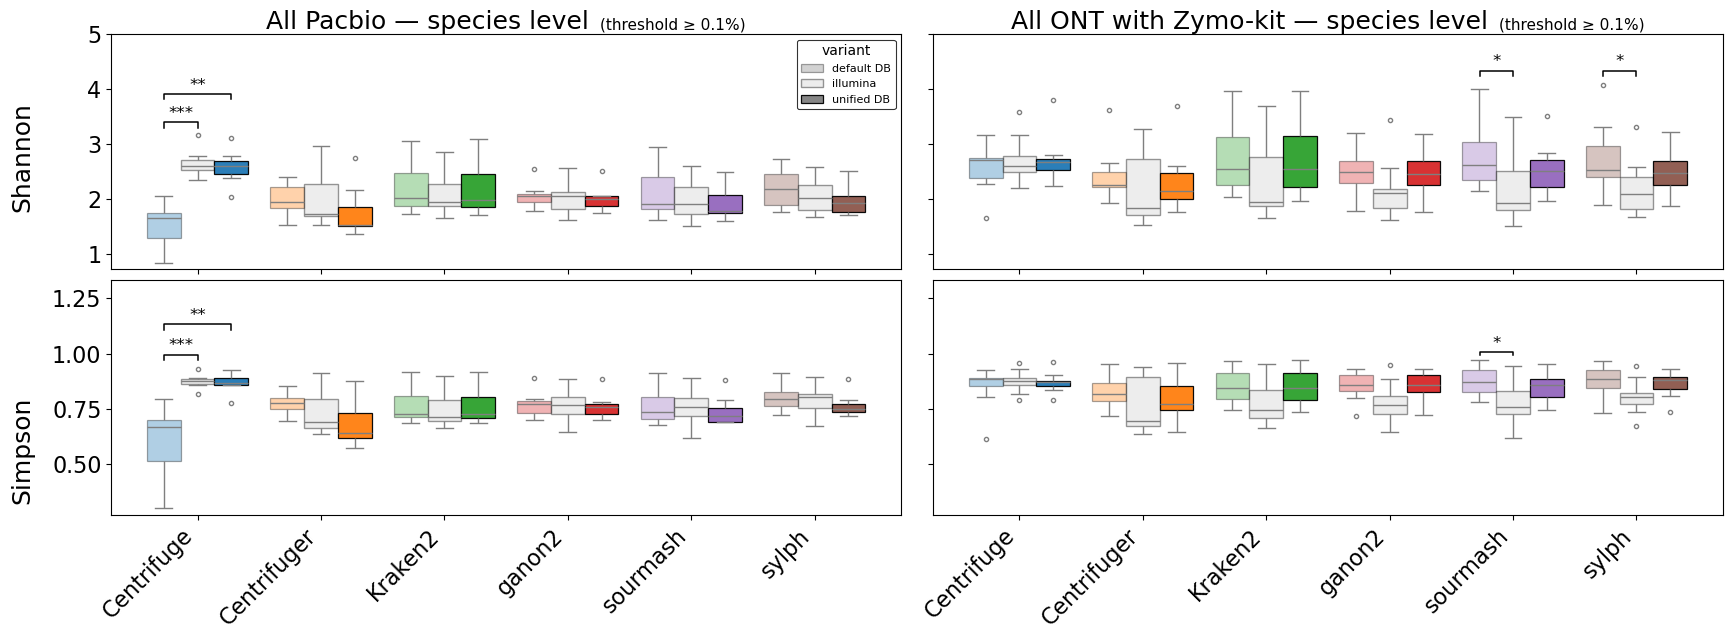

In [49]:
cohort_a, cohort_b = PLOT_TWO_COHORTS
plot_alpha_cohorts(
    alpha_df,
    cohorts=PLOT_TWO_COHORTS,
    rank="species",                  # run again with rank="genus"
    metrics=("shannon", "simpson"),
    figsize=(18, 6.5),
    box_width=0.82,
    dodge_offset=0.27,
    headroom_frac=0.08,
    show_only_significant=True,
    alpha_sig=0.05,
    filename=OUT_FIG / f"alpha_species_{cohort_a}_vs_{cohort_b}_rawp",
)


[saved] /home/Users/pacbio_bakeoff/bakeoff/results/20260713_015342_dyn/dyn-alpha-div/figures/threshold_0.1/alpha_genus_pacbio_vs_ont_zymo_rawp.png


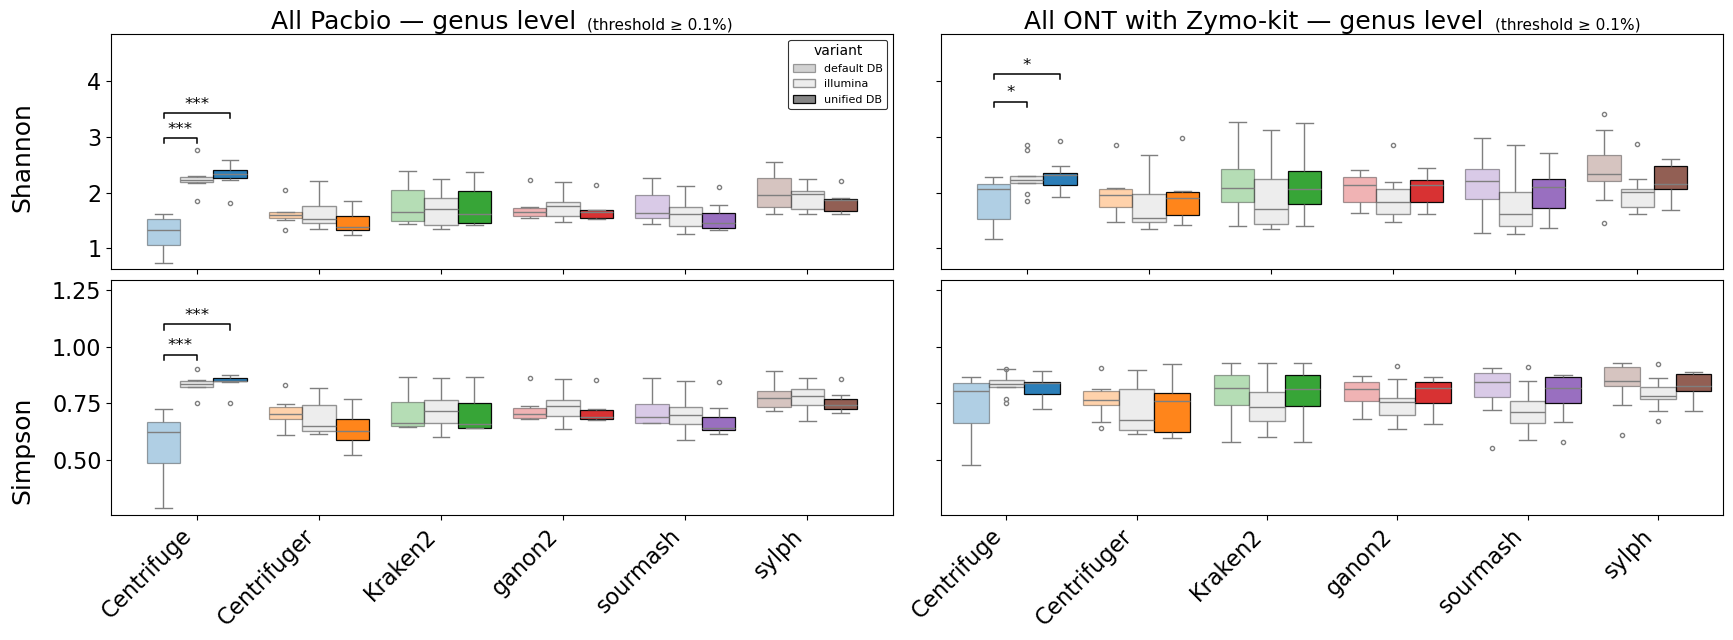

In [50]:
cohort_a, cohort_b = PLOT_TWO_COHORTS
plot_alpha_cohorts(
    alpha_df,
    cohorts=PLOT_TWO_COHORTS,
    rank="genus",
    metrics=("shannon", "simpson"),
    figsize=(18, 6.5),
    box_width=0.82,
    dodge_offset=0.27,
    headroom_frac=0.08,
    show_only_significant=True,
    alpha_sig=0.05,
    filename=OUT_FIG / f"alpha_genus_{cohort_a}_vs_{cohort_b}_rawp",
)


## Section 2 — Alpha-diversity figures (BH-FDR q-value asterisks)

The same boxplots, but asterisks denote **Benjamini–Hochberg FDR-adjusted q-values**
(\* q<0.05, \*\* q<0.01, \*\*\* q<0.001). The dumbbell at the end shows which
nominally-significant comparisons survive correction. Data: `alpha_div_mwu_bhfdr.tsv`.

[saved] /home/Users/pacbio_bakeoff/bakeoff/results/20260713_015342_dyn/dyn-alpha-div/figures/threshold_0.1/alpha_species_pacbio_vs_ont_zymo_bhfdr.png


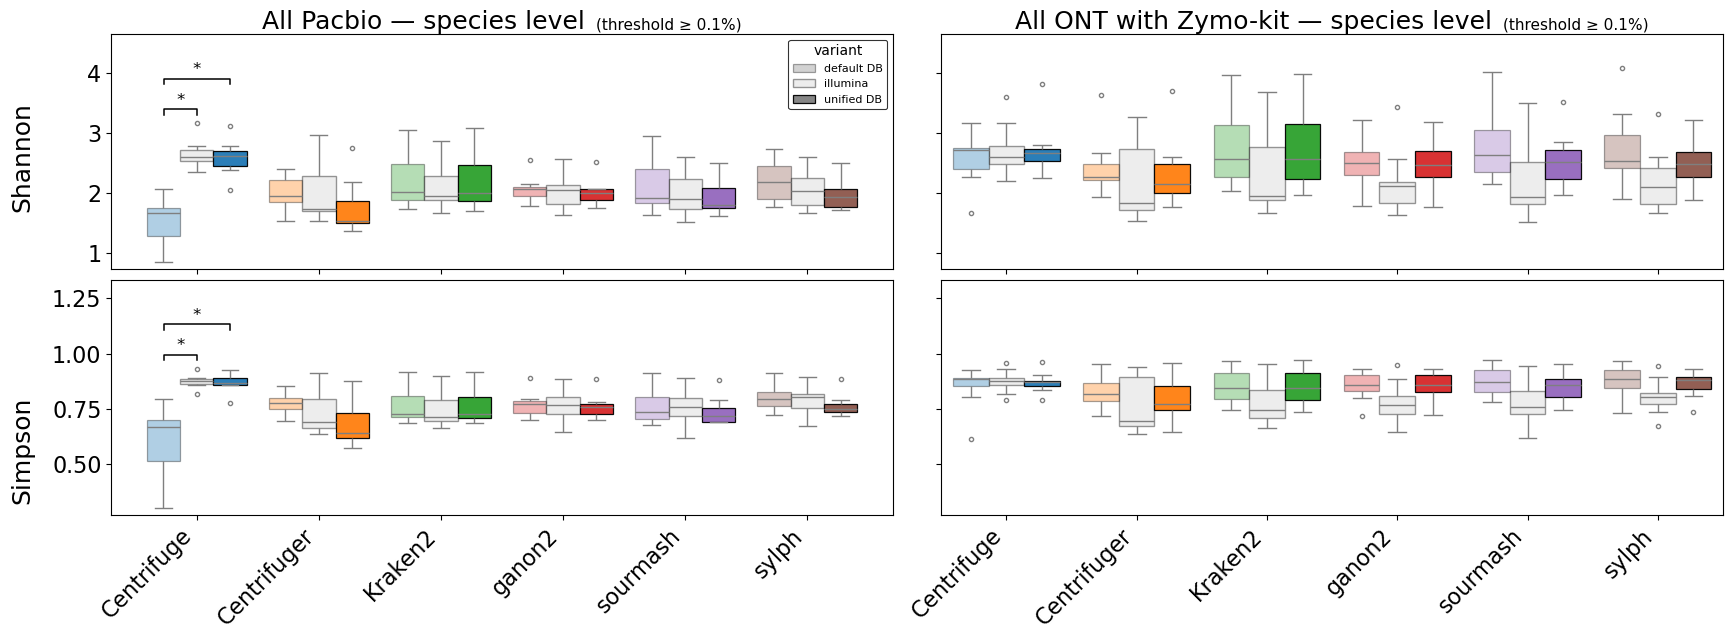

In [51]:
cohort_a, cohort_b = PLOT_TWO_COHORTS
plot_alpha_cohorts(
    alpha_df,
    cohorts=PLOT_TWO_COHORTS,
    rank="species",
    metrics=("shannon", "simpson"),
    figsize=(18, 6.5),
    box_width=0.82,
    dodge_offset=0.27,
    headroom_frac=0.08,
    show_only_significant=True,
    alpha_sig=0.05,
    sig_lookup=q_lookup,          # BH-adjusted q drives the asterisks
    filename=OUT_FIG / f"alpha_species_{cohort_a}_vs_{cohort_b}_bhfdr",
)


[saved] /home/Users/pacbio_bakeoff/bakeoff/results/20260713_015342_dyn/dyn-alpha-div/figures/threshold_0.1/alpha_genus_pacbio_vs_ont_zymo_bhfdr.png


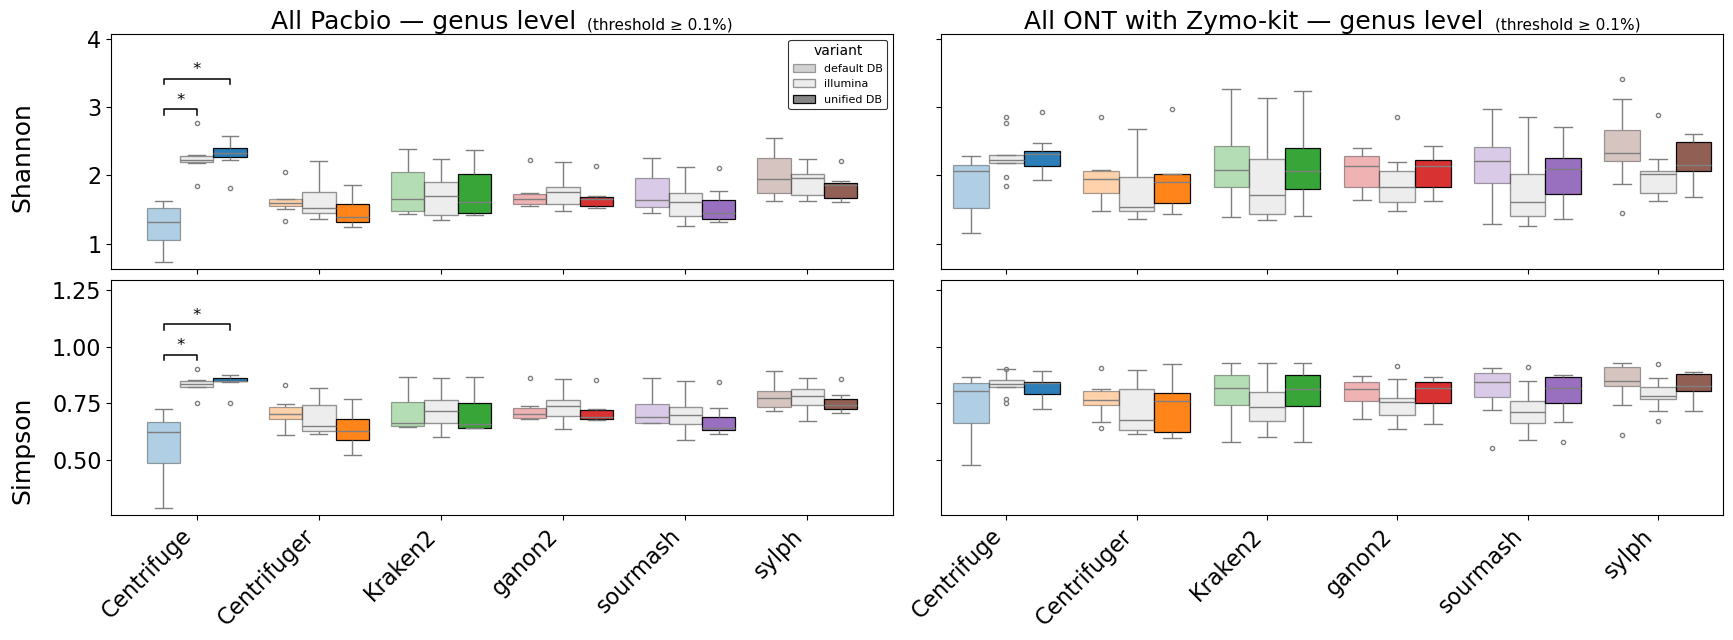

In [52]:
cohort_a, cohort_b = PLOT_TWO_COHORTS
plot_alpha_cohorts(
    alpha_df,
    cohorts=PLOT_TWO_COHORTS,
    rank="genus",
    metrics=("shannon", "simpson"),
    figsize=(18, 6.5),
    box_width=0.82,
    dodge_offset=0.27,
    headroom_frac=0.08,
    show_only_significant=True,
    alpha_sig=0.05,
    sig_lookup=q_lookup,          # BH-adjusted q drives the asterisks
    filename=OUT_FIG / f"alpha_genus_{cohort_a}_vs_{cohort_b}_bhfdr",
)


### Single-cohort panel (Fig S8) - BH-FDR q-value asterisks


[saved] /home/Users/pacbio_bakeoff/bakeoff/results/20260713_015342_dyn/dyn-alpha-div/figures/threshold_0.1/ont_qiagen_alpha_div_bhfdr.png


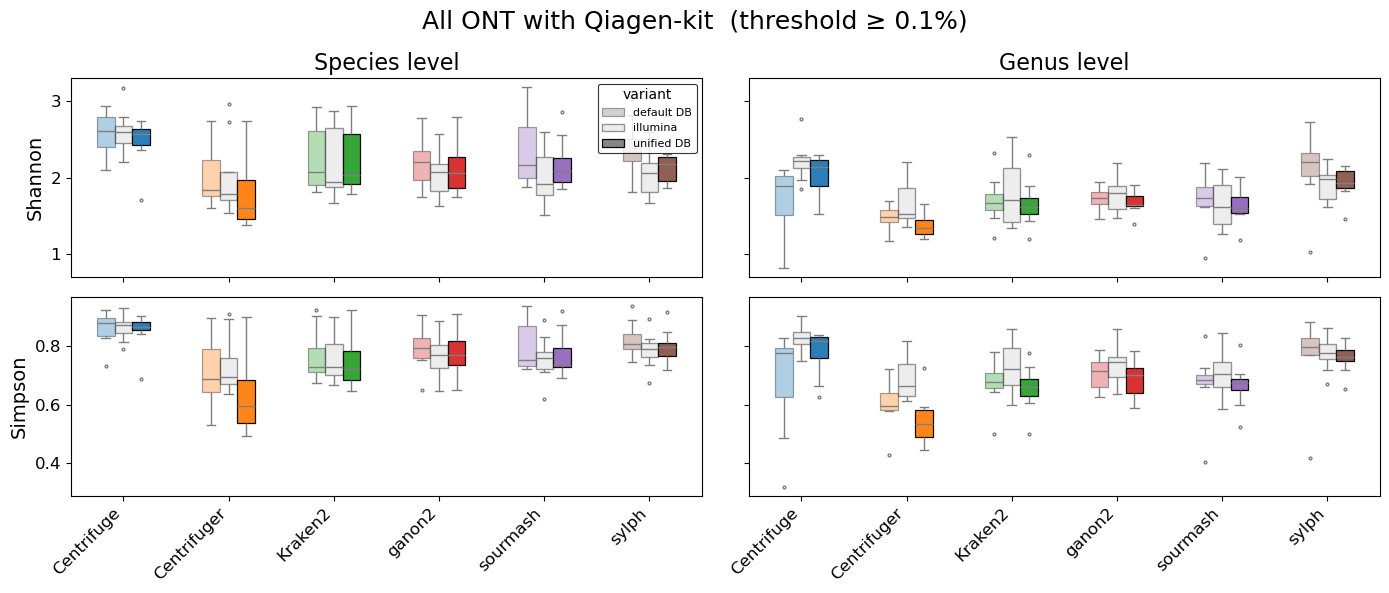

In [53]:
# BH-FDR version of the single-cohort panel; q-values come from the shared family above.
plot_alpha_db_with_illumina_panel(
    alpha_df,
    cohort=PLOT_SINGLE_COHORT,
    metrics=("shannon", "simpson"),
    ranks=("species", "genus"),
    filename=OUT_FIG / f"{PLOT_SINGLE_COHORT}_alpha_div_bhfdr",
    box_width=0.50,
    dodge_offset=0.17,
    headroom_frac=0.05,
    show_only_significant=True,
    alpha_sig=0.05,
    sig_lookup=q_lookup,          # BH-adjusted q drives the asterisks
)